In [38]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import preprocessing

# defining paths for notebook
current_dir = Path(globals()["_dh"][0])

data_path = os.path.join(current_dir, "data")

In [112]:
features = [
    "Age",
    "Lifetime",
    "Contract_period",
    "Avg_class_frequency_current_month",
    "Avg_class_frequency_total",
    "Avg_additional_charges_total",
]

df = pd.read_csv(os.path.join(data_path, "gym_churn_us.csv"), usecols=features)
y = pd.read_csv(os.path.join(data_path, "gym_churn_us.csv"), usecols=["Churn"])
y = y["Churn"].copy()

df.head()

,Contract_period,Age,Avg_additional_charges_total,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
0,6,29,14.227470,3,0.020398,0.000000
1,12,31,113.202938,7,1.922936,1.910244
2,1,28,129.448479,2,1.859098,1.736502
3,12,33,62.669863,2,3.205633,3.357215
4,1,26,198.362265,3,1.113884,1.120078


In [66]:
scaled_data = preprocessing.scale(df)

In [79]:
pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)

In [80]:
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels = ["PC" + str(x) for x in range(1, len(per_var) + 1)]

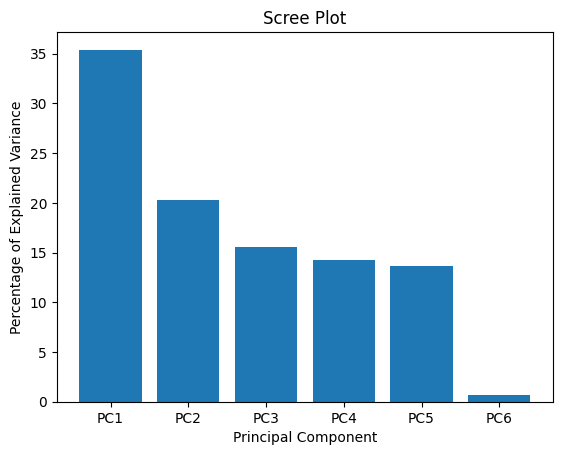

In [81]:
plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel("Percentage of Explained Variance")
plt.xlabel("Principal Component")
plt.title("Scree Plot")
plt.show()

In [82]:
pca_df = pd.DataFrame(pca_data, index=df.index, columns=labels)

In [120]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
pca_data

array([[-2.45654103,  0.5529341 ],
       [ 0.78645005,  1.25013484],
       [-0.43973141, -0.83236841],
       ...,
       [ 1.30890793, -0.43757289],
       [-0.14847526,  0.17980065],
       [-0.66355186,  1.16498529]], shape=(4000, 2))

Text(0, 0.5, 'PC2 - 20.3%')

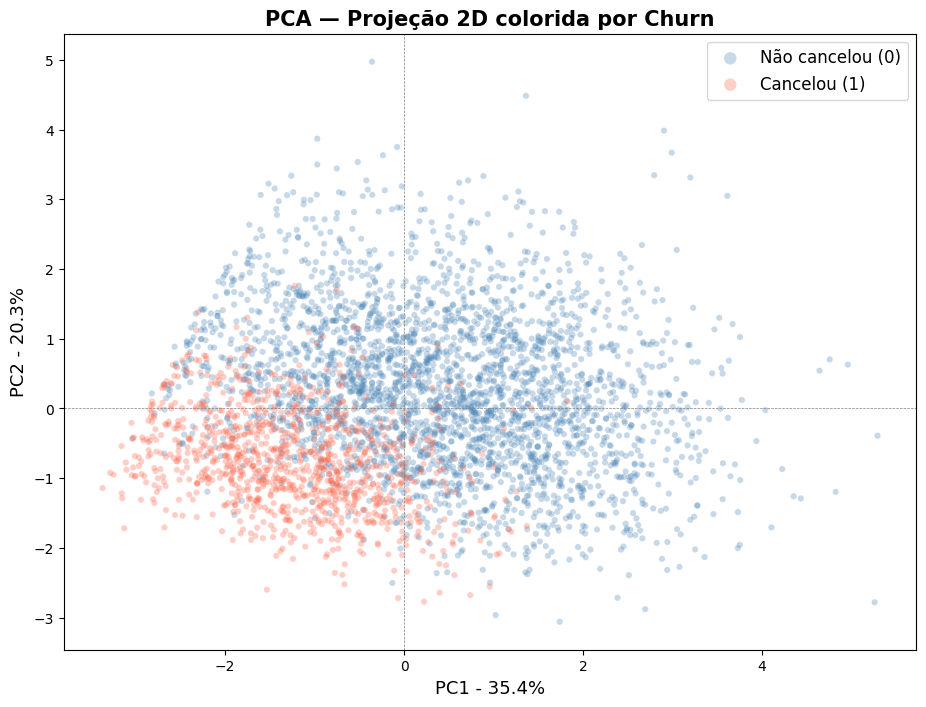

In [122]:
colors = {0: "steelblue", 1: "tomato"}
labels = {0: "Não cancelou (0)", 1: "Cancelou (1)"}

fig, ax = plt.subplots(figsize=(11, 8))

for churn_val in [0, 1]:
    mask = y == churn_val
    ax.scatter(
        pca_data[mask, 0],
        pca_data[mask, 1],
        c=colors[churn_val],
        label=labels[churn_val],
        alpha=0.3,
        s=20,
        edgecolors="none",
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variância)", fontsize=13
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variância)", fontsize=13
)
ax.set_title("PCA — Projeção 2D colorida por Churn", fontsize=15, fontweight="bold")
ax.legend(fontsize=12, markerscale=2)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
plt.xlabel("PC1 - {0}%".format(per_var[0]))
plt.ylabel("PC2 - {0}%".format(per_var[1]))

In [116]:
## get the name of the top 10 measurements (genes) that contribute
## most to pc1.
## first, get the loading scores
loading_scores = pd.Series(pca.components_[0], index=df.columns)
## now sort the loading scores based on their magnitude
sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)

# get the names of the top 10 genes
top_10_genes = sorted_loading_scores[0:10].index.values

## print the gene names and their scores (and +/- sign)
print(loading_scores[top_10_genes])

Avg_class_frequency_current_month    0.649459
Avg_class_frequency_total            0.624743
Lifetime                             0.246372
Age                                  0.245067
Contract_period                      0.225487
Avg_additional_charges_total         0.127663
dtype: float64


In [117]:
# Loadings — contribuição de cada variável em cada componente
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=features)

print("Loadings (contribuição das variáveis nos componentes):")
print(loadings.round(4))

Loadings (contribuição das variáveis nos componentes):
                                      PC1     PC2
Age                                0.2255  0.5013
Lifetime                           0.2451  0.4169
Contract_period                    0.1277  0.4148
Avg_class_frequency_current_month  0.2464  0.4658
Avg_class_frequency_total          0.6247 -0.3463
Avg_additional_charges_total       0.6495 -0.2566
